In [1]:
!pip install open_clip_torch matplotlib

Running on cpu with ViT-B-32
Starting Training...
Epoch [1/10] Loss: 1.7149
Epoch [2/10] Loss: 1.2700
Epoch [3/10] Loss: 1.0987
Epoch [4/10] Loss: 1.0026
Epoch [5/10] Loss: 0.9853
Epoch [6/10] Loss: 0.9954
Epoch [7/10] Loss: 0.9646
Epoch [8/10] Loss: 0.9813
Epoch [9/10] Loss: 0.9388
Epoch [10/10] Loss: 0.9389
Training Complete!


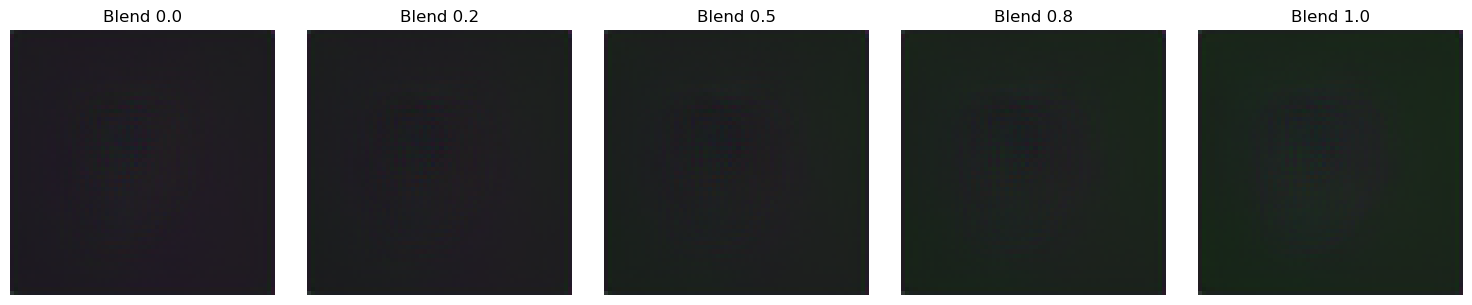

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import os

# -----------------------------------------------------------------------------
# 0. CONFIGURATION & SETUP
# -----------------------------------------------------------------------------
# Ensure you have installed: pip install open_clip_torch matplotlib
try:
    import open_clip
except ImportError:
    print("Please install open_clip: pip install open_clip_torch")
    exit()

CONFIG = {
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "batch_size": 64,
    "lr": 1e-4,
    "epochs": 10,  # Increase to 50+ for good results
    "img_size": 64,
    "embed_dim": 512, # ViT-B-32 dimension
    "clip_model": "ViT-B-32",
    "clip_pretrained": "laion2b_s34b_b79k", # Fast, standard weights
}

print(f"Running on {CONFIG['device']} with {CONFIG['clip_model']}")

# -----------------------------------------------------------------------------
# 1. DATASET: SYNTHETIC SHAPES (To make this instantly runnable)
# -----------------------------------------------------------------------------
class SyntheticShapes(Dataset):
    """
    Generates random colorful shapes on the fly. 
    Replaces need for COCO/OpenImages for this demo.
    """
    def __init__(self, size=64, num_samples=2000):
        self.size = size
        self.num_samples = num_samples
        self.transform = T.Compose([
            T.ToTensor(),
            T.Normalize((0.5,), (0.5,)) # Normalize to [-1, 1] for Generator
        ])

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Generate a random image using PIL
        img = Image.new('RGB', (self.size, self.size), color=tuple(np.random.randint(0, 50, 3)))
        draw = ImageDraw.Draw(img)
        
        # Random primitives
        for _ in range(np.random.randint(3, 6)):
            shape_type = np.random.choice(['rect', 'circle'])
            color = tuple(np.random.randint(50, 255, 3))
            xy = np.random.randint(0, self.size, 4)
            
            if shape_type == 'rect':
                draw.rectangle(list(xy), fill=color)
            else:
                draw.ellipse(list(xy), fill=color)
        
        return self.transform(img)

# -----------------------------------------------------------------------------
# 2. MODELS: ENCODER (Frozen CLIP) & DECODER (Trainable)
# -----------------------------------------------------------------------------

class CLIPEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Load OpenCLIP model
        self.model, _, self.preprocess = open_clip.create_model_and_transforms(
            CONFIG['clip_model'], pretrained=CONFIG['clip_pretrained']
        )
        self.model.eval() # Always eval
        self.model.to(CONFIG['device'])
        
        # Standard normalization for CLIP (different from GAN normalization)
        self.clip_normalize = T.Normalize(
            mean=(0.48145466, 0.4578275, 0.40821073),
            std=(0.26862954, 0.26130258, 0.27577711)
        )

    @torch.no_grad()
    def forward(self, images):
        # Images come in as [-1, 1] (from generator standards)
        # Denormalize to [0, 1] then normalize for CLIP
        x = (images + 1) * 0.5 
        x = torch.clamp(x, 0, 1)
        
        # Resize to 224 for CLIP if needed (ViT-B/32 expects 224)
        x = torch.nn.functional.interpolate(x, size=(224, 224), mode='bicubic')
        x = self.clip_normalize(x)
        
        features = self.model.encode_image(x)
        return features.float() # Return raw embeddings

class ResBlock(nn.Module):
    """Simple Residual Block for the Decoder"""
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels),
            nn.ReLU(True),
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels)
        )
        self.relu = nn.ReLU(True)

    def forward(self, x):
        return self.relu(x + self.block(x))

class ImageDecoder(nn.Module):
    """
    Expands CLIP embeddings (512) back to Images (3, 64, 64).
    Structure: FC -> 4x4 -> Upsample Blocks
    """
    def __init__(self, embed_dim=512):
        super().__init__()
        
        # Initial projection: 512 -> 256 * 4 * 4
        self.init_size = 4
        self.dim = 256
        self.fc = nn.Linear(embed_dim, self.dim * self.init_size * self.init_size)
        
        self.blocks = nn.Sequential(
            # 4x4 -> 8x8
            nn.Upsample(scale_factor=2),
            nn.Conv2d(self.dim, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            ResBlock(256),
            
            # 8x8 -> 16x16
            nn.Upsample(scale_factor=2),
            nn.Conv2d(256, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            ResBlock(128),

            # 16x16 -> 32x32
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            ResBlock(64),
            
            # 32x32 -> 64x64
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 32, 3, 1, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            ResBlock(32),
            
            # Final projection to RGB
            nn.Conv2d(32, 3, 3, 1, 1),
            nn.Tanh() # Output [-1, 1]
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, self.dim, self.init_size, self.init_size)
        return self.blocks(x)

# -----------------------------------------------------------------------------
# 3. LOSS FUNCTIONS (L1 + VGG Perceptual)
# -----------------------------------------------------------------------------

class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
        # Slice 1: Layers 0-3 (RGB -> 64 channels)
        self.slice1 = nn.Sequential(*[vgg[x] for x in range(4)]).eval()
        # Slice 2: Layers 4-8 (64 -> 128 channels)
        self.slice2 = nn.Sequential(*[vgg[x] for x in range(4, 9)]).eval()
        
        for param in self.parameters():
            param.requires_grad = False
            
    def forward(self, input, target):
        # Input/Target assumed to be [-1, 1]
        input = (input + 1) * 0.5
        target = (target + 1) * 0.5
        
        # Standardize for VGG
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(input.device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(input.device)
        input = (input - mean) / std
        target = (target - mean) / std
        
        # --- FIX: CHAIN THE INPUTS ---
        # Pass output of slice1 into slice2 (not the original image)
        input_feat1 = self.slice1(input)
        input_feat2 = self.slice2(input_feat1) 
        
        target_feat1 = self.slice1(target)
        target_feat2 = self.slice2(target_feat1)
        
        loss = torch.nn.functional.l1_loss(input_feat1, target_feat1)
        loss += torch.nn.functional.l1_loss(input_feat2, target_feat2)
        return loss

# -----------------------------------------------------------------------------
# 4. MAIN TRAINING LOOP
# -----------------------------------------------------------------------------

def main():
    # Setup
    dataset = SyntheticShapes(size=CONFIG['img_size'], num_samples=2000)
    dataloader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True)
    
    encoder = CLIPEncoder()
    decoder = ImageDecoder(embed_dim=CONFIG['embed_dim']).to(CONFIG['device'])
    
    optimizer = optim.AdamW(decoder.parameters(), lr=CONFIG['lr'])
    
    criterion_pixel = nn.L1Loss()
    criterion_perceptual = VGGPerceptualLoss().to(CONFIG['device'])
    
    print("Starting Training...")
    
    for epoch in range(CONFIG['epochs']):
        decoder.train()
        total_loss = 0
        
        for images in dataloader:
            images = images.to(CONFIG['device'])
            
            # 1. Get Embeddings (Ground Truth)
            with torch.no_grad():
                embeddings = encoder(images)
                
                # Normalize embeddings (Important for CLIP space consistency)
                embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)
            
            # 2. Decode
            recon_images = decoder(embeddings)
            
            # 3. Compute Loss
            loss_pix = criterion_pixel(recon_images, images)
            loss_vgg = criterion_perceptual(recon_images, images)
            loss = loss_pix + (0.5 * loss_vgg)
            
            # 4. Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
        print(f"Epoch [{epoch+1}/{CONFIG['epochs']}] Loss: {total_loss/len(dataloader):.4f}")
        
    print("Training Complete!")
    return encoder, decoder

# -----------------------------------------------------------------------------
# 5. BLENDING & VISUALIZATION
# -----------------------------------------------------------------------------

def blend_images(encoder, decoder, steps=5):
    """
    Demonstrates the blender capability.
    Generates two random images, encodes them, mixes embeddings, decodes.
    """
    decoder.eval()
    
    # Create two random test images
    ds = SyntheticShapes(size=64, num_samples=2)
    img1 = ds[0].unsqueeze(0).to(CONFIG['device'])
    img2 = ds[1].unsqueeze(0).to(CONFIG['device'])
    
    with torch.no_grad():
        emb1 = encoder(img1)
        emb2 = encoder(img2)
        
        # Slerp (Spherical Linear Interpolation) is better for CLIP space, 
        # but Linear Interp (Lerp) works fine for simple tests.
        # We will use simple Linear here for readability.
        
        alphas = np.linspace(0, 1, steps)
        fig, axes = plt.subplots(1, steps, figsize=(15, 3))
        
        for i, alpha in enumerate(alphas):
            # Mix the vectors
            mixed_emb = (1 - alpha) * emb1 + alpha * emb2
            
            # Normalize again (vectors must stay on the hypersphere)
            mixed_emb = mixed_emb / mixed_emb.norm(dim=-1, keepdim=True)
            
            # Decode
            result = decoder(mixed_emb)
            
            # Convert to display
            res_img = result.squeeze().cpu().permute(1, 2, 0).numpy()
            res_img = (res_img + 1) / 2.0 # [-1, 1] -> [0, 1]
            
            axes[i].imshow(np.clip(res_img, 0, 1))
            axes[i].axis('off')
            axes[i].set_title(f"Blend {alpha:.1f}")
            
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    enc, dec = main()
    blend_images(enc, dec)

Running STL-10 Context Blender on cpu...
Downloading/Loading STL-10 (this might take a minute)...


100%|██████████| 2640397119/2640397119 [16:55<00:00, 2599146.40it/s] 


Extracting ./data/stl10_binary.tar.gz to ./data
Starting training on 5000 images...
Epoch 1 | Batch 0 | Loss: 1.2116
Epoch 1 | Batch 20 | Loss: 0.9082
Epoch 1 | Batch 40 | Loss: 0.8420
Epoch 1 | Batch 60 | Loss: 0.7504
=== Epoch 1 Complete. Avg Loss: 0.8712 ===
Epoch 2 | Batch 0 | Loss: 0.7175
Epoch 2 | Batch 20 | Loss: 0.7912
Epoch 2 | Batch 40 | Loss: 0.7285
Epoch 2 | Batch 60 | Loss: 0.7730
=== Epoch 2 Complete. Avg Loss: 0.7584 ===
Epoch 3 | Batch 0 | Loss: 0.7165
Epoch 3 | Batch 20 | Loss: 0.7256
Epoch 3 | Batch 40 | Loss: 0.6691
Epoch 3 | Batch 60 | Loss: 0.7372
=== Epoch 3 Complete. Avg Loss: 0.7150 ===
Epoch 4 | Batch 0 | Loss: 0.6466
Epoch 4 | Batch 20 | Loss: 0.7492
Epoch 4 | Batch 40 | Loss: 0.7291
Epoch 4 | Batch 60 | Loss: 0.7032
=== Epoch 4 Complete. Avg Loss: 0.6927 ===
Epoch 5 | Batch 0 | Loss: 0.6562
Epoch 5 | Batch 20 | Loss: 0.6497
Epoch 5 | Batch 40 | Loss: 0.6998
Epoch 5 | Batch 60 | Loss: 0.6132
=== Epoch 5 Complete. Avg Loss: 0.6699 ===
Epoch 6 | Batch 0 | Loss: 

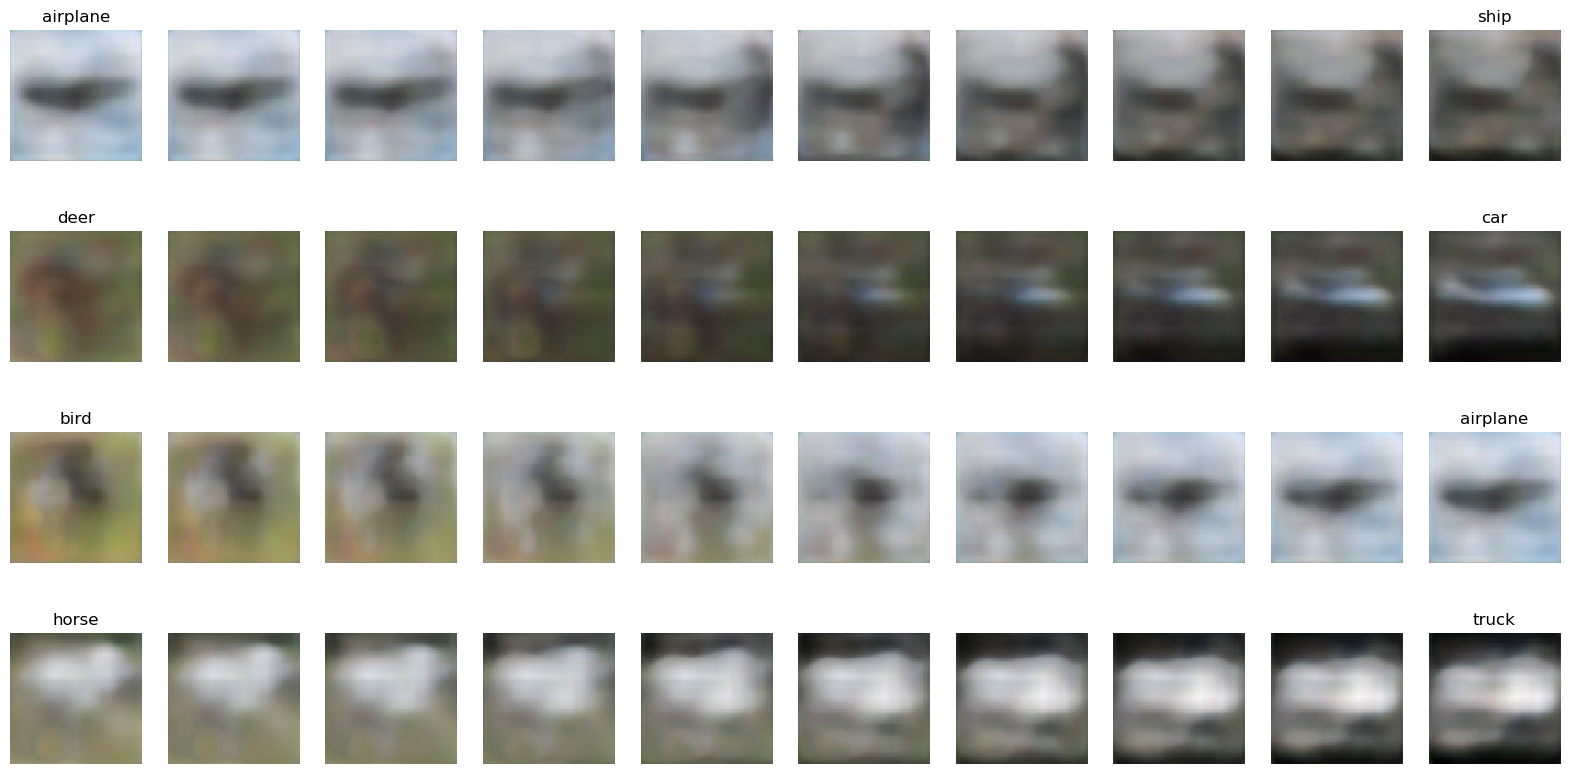

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as T
import torchvision.datasets as datasets
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------------------------------------------------------
# 0. CONFIGURATION
# -----------------------------------------------------------------------------
try:
    import open_clip
except ImportError:
    print("Please install open_clip: pip install open_clip_torch")
    exit()

CONFIG = {
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "batch_size": 64,      # Good balance for CPU/GPU
    "lr": 1e-3,            # Higher LR for faster convergence on small data
    "epochs": 10,          # 10 epochs is enough to see concepts form
    "img_size": 96,        # STL-10 Native Resolution
    "embed_dim": 512,      # ViT-B-32
    "output_dir": "stl10_outputs"
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
print(f"Running STL-10 Context Blender on {CONFIG['device']}...")

# -----------------------------------------------------------------------------
# 1. DATASET: STL-10 (96x96 Real Images)
# -----------------------------------------------------------------------------
def get_stl10_loader():
    print("Downloading/Loading STL-10 (this might take a minute)...")
    
    # STL-10 Normalization
    stats = ((0.4467, 0.4398, 0.4066), (0.2603, 0.2566, 0.2713))
    
    transform = T.Compose([
        T.Resize(CONFIG['img_size']), # Explicitly ensure 96x96
        T.ToTensor(),
        T.Normalize(*stats)
    ])
    
    # We use the 'train' split (5000 labeled images) for speed.
    # The 'unlabeled' split is huge (100k) and would take too long to train on CPU.
    dataset = datasets.STL10(root='./data', split='train', download=True, transform=transform)
    
    loader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True)
    return loader, dataset, stats

# -----------------------------------------------------------------------------
# 2. MODELS: CLIP ENCODER & UPSAMPLE DECODER
# -----------------------------------------------------------------------------
class CLIPEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.model, _, _ = open_clip.create_model_and_transforms(
            'ViT-B-32', pretrained='laion2b_s34b_b79k'
        )
        self.model.eval()
        self.model.to(CONFIG['device'])
        
        # Norm constants for CLIP
        self.register_buffer("mean", torch.tensor([0.481, 0.457, 0.408]).view(1,3,1,1))
        self.register_buffer("std", torch.tensor([0.268, 0.261, 0.275]).view(1,3,1,1))

    @torch.no_grad()
    def forward(self, images, denorm_stats):
        # 1. Denorm from STL-10 stats
        dm, ds = denorm_stats
        x = images * torch.tensor(ds).view(1,3,1,1).to(CONFIG['device']) + \
            torch.tensor(dm).view(1,3,1,1).to(CONFIG['device'])
            
        # 2. Resize to 224 for CLIP
        x = torch.nn.functional.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        
        # 3. Norm for CLIP
        x = (x - self.mean) / self.std
        
        features = self.model.encode_image(x)
        return features.float() / features.norm(dim=-1, keepdim=True)

class ContextDecoder(nn.Module):
    """
    Decodes 512-dim embedding back to 96x96 image.
    Uses upsampling blocks.
    """
    def __init__(self, embed_dim=512):
        super().__init__()
        
        # Start at 6x6 spatial dim (6 * 16 = 96)
        self.init_h = 6 
        self.dim = 256
        
        self.fc = nn.Linear(embed_dim, self.dim * self.init_h * self.init_h)
        
        self.blocks = nn.Sequential(
            # 6x6 -> 12x12
            nn.Upsample(scale_factor=2),
            nn.Conv2d(256, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            
            # 12x12 -> 24x24
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            
            # 24x24 -> 48x48
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            
            # 48x48 -> 96x96
            nn.Upsample(scale_factor=2),
            nn.Conv2d(32, 16, 3, 1, 1), nn.BatchNorm2d(16), nn.ReLU(True),
            
            # Final Polish
            nn.Conv2d(16, 3, 3, 1, 1)
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, self.dim, self.init_h, self.init_h)
        return self.blocks(x)

# -----------------------------------------------------------------------------
# 3. TRAINING LOOP
# -----------------------------------------------------------------------------
def train_stl10():
    loader, dataset, stats = get_stl10_loader()
    
    encoder = CLIPEncoder()
    decoder = ContextDecoder().to(CONFIG['device'])
    
    # We use MSE because it's stable and fast for this demo.
    # Perceptual loss is better but much heavier on CPU.
    optimizer = optim.Adam(decoder.parameters(), lr=CONFIG['lr'])
    criterion = nn.MSELoss()
    
    print(f"Starting training on {len(dataset)} images...")
    
    for epoch in range(CONFIG['epochs']):
        decoder.train()
        total_loss = 0
        
        for batch_idx, (images, _) in enumerate(loader):
            images = images.to(CONFIG['device'])
            
            with torch.no_grad():
                # CLIP understands the SCENE here (Sky, Grass, Fur)
                embeddings = encoder(images, stats)
            
            recon = decoder(embeddings)
            loss = criterion(recon, images)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            if batch_idx % 20 == 0:
                print(f"Epoch {epoch+1} | Batch {batch_idx} | Loss: {loss.item():.4f}")
        
        avg_loss = total_loss / len(loader)
        print(f"=== Epoch {epoch+1} Complete. Avg Loss: {avg_loss:.4f} ===")
        
        # Save checkpoint every epoch just in case
        torch.save(decoder.state_dict(), f"{CONFIG['output_dir']}/decoder_epoch_{epoch+1}.pt")

    return encoder, decoder, stats, dataset

# -----------------------------------------------------------------------------
# 4. CONTEXT BLENDING VIZ
# -----------------------------------------------------------------------------
def visualize_context_blends(encoder, decoder, stats, dataset):
    print("Generating Contextual Blends...")
    decoder.eval()
    
    # STL-10 Classes:
    # 0: airplane, 1: bird, 2: car, 3: cat, 4: deer, 
    # 5: dog, 6: horse, 7: monkey, 8: ship, 9: truck
    
    # We want specific transitions that require Context Swapping
    # e.g. Plane (Sky) -> Ship (Ocean)
    # e.g. Deer (Grass) -> Car (Road)
    
    class_map = {
        0: 'airplane', 1: 'bird', 2: 'car', 3: 'cat', 4: 'deer',
        5: 'dog', 6: 'horse', 7: 'monkey', 8: 'ship', 9: 'truck'
    }
    
    # Find 1 example of each class
    examples = {}
    indices = np.random.permutation(len(dataset))
    for idx in indices:
        img, label = dataset[idx]
        if label not in examples:
            examples[label] = img
        if len(examples) == 10: break
    
    # Define interesting pairs
    pairs = [
        (0, 8), # Airplane -> Ship (Sky -> Ocean)
        (4, 2), # Deer -> Car (Nature -> Street)
        (1, 0), # Bird -> Airplane (Biologic -> Mechanic)
        (6, 9), # Horse -> Truck (Animal Transport -> Machine Transport)
    ]
    
    steps = 10
    fig, axes = plt.subplots(len(pairs), steps, figsize=(20, 2.5 * len(pairs)))
    
    dm, ds = stats
    mean = torch.tensor(dm).view(1,3,1,1)
    std = torch.tensor(ds).view(1,3,1,1)

    with torch.no_grad():
        for row, (c1, c2) in enumerate(pairs):
            img1 = examples[c1].unsqueeze(0).to(CONFIG['device'])
            img2 = examples[c2].unsqueeze(0).to(CONFIG['device'])
            
            emb1 = encoder(img1, stats)
            emb2 = encoder(img2, stats)
            
            # Slerp
            theta = torch.acos(torch.sum(emb1 * emb2))
            sin_theta = torch.sin(theta)
            
            for col, alpha in enumerate(np.linspace(0, 1, steps)):
                if sin_theta < 1e-6:
                    mixed = (1-alpha)*emb1 + alpha*emb2
                else:
                    w1 = torch.sin((1-alpha)*theta) / sin_theta
                    w2 = torch.sin(alpha*theta) / sin_theta
                    mixed = w1*emb1 + w2*emb2
                
                recon = decoder(mixed)
                
                # De-norm for viz
                viz = recon.cpu() * std + mean
                viz = viz.clamp(0, 1).squeeze().permute(1, 2, 0).numpy()
                
                ax = axes[row, col] if len(pairs) > 1 else axes[col]
                ax.imshow(viz)
                ax.axis('off')
                
                if col == 0: ax.set_title(class_map[c1])
                if col == steps - 1: ax.set_title(class_map[c2])

    save_path = f"{CONFIG['output_dir']}/stl10_blends.png"
    plt.savefig(save_path, bbox_inches='tight')
    print(f"Visualization saved to {save_path}")

if __name__ == "__main__":
    enc, dec, stats, ds = train_stl10()
    visualize_context_blends(enc, dec, stats, ds)

Running STL-10 GAN on cpu...
Files already downloaded and verified
Starting GAN Training on 5000 images...
Epoch 1 | D: 0.6730 | G_Adv: 3.0310 | G_Rec: 0.5196
Epoch 1 | D: 0.8204 | G_Adv: 1.0346 | G_Rec: 0.3824
Epoch 2 | D: 0.6194 | G_Adv: 1.2145 | G_Rec: 0.3791
Epoch 2 | D: 0.4861 | G_Adv: 1.4793 | G_Rec: 0.4021
Epoch 3 | D: 0.4598 | G_Adv: 1.7272 | G_Rec: 0.3871
Epoch 3 | D: 0.3602 | G_Adv: 2.3706 | G_Rec: 0.4001
Epoch 4 | D: 0.4622 | G_Adv: 2.3803 | G_Rec: 0.3908
Epoch 4 | D: 0.4163 | G_Adv: 1.9978 | G_Rec: 0.4108
Epoch 5 | D: 0.5905 | G_Adv: 2.9279 | G_Rec: 0.4072
Epoch 5 | D: 0.5370 | G_Adv: 2.9262 | G_Rec: 0.4034
Epoch 6 | D: 0.5942 | G_Adv: 2.8246 | G_Rec: 0.3827
Epoch 6 | D: 0.3546 | G_Adv: 2.6940 | G_Rec: 0.4028
Epoch 7 | D: 0.2449 | G_Adv: 3.2735 | G_Rec: 0.3897
Epoch 7 | D: 0.4063 | G_Adv: 2.4933 | G_Rec: 0.3979
Epoch 8 | D: 0.4235 | G_Adv: 2.0251 | G_Rec: 0.3941
Epoch 8 | D: 1.1043 | G_Adv: 0.4887 | G_Rec: 0.3780
Epoch 9 | D: 0.3827 | G_Adv: 2.0366 | G_Rec: 0.3849
Epoch 9 |

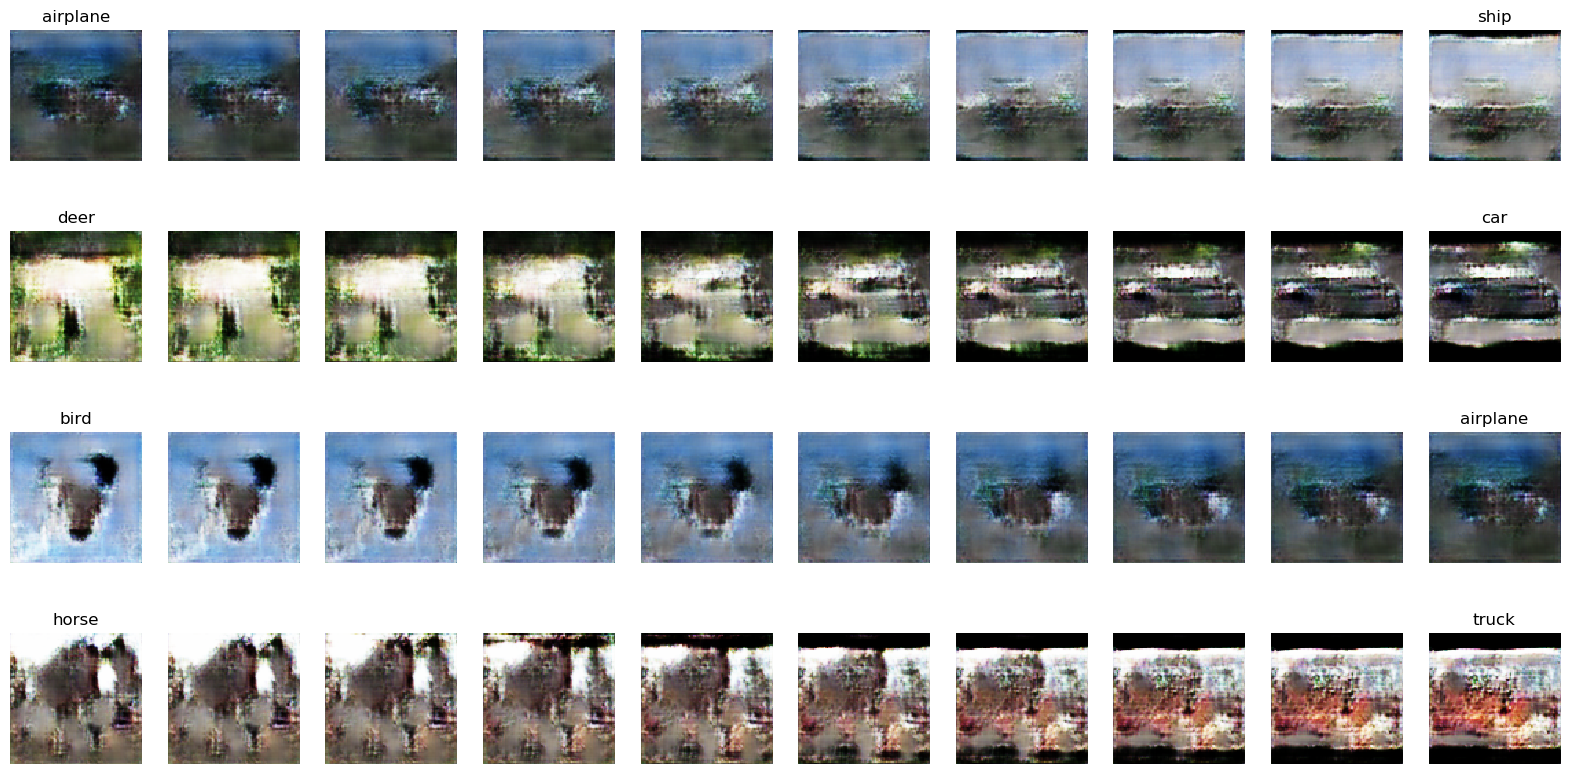

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as T
import torchvision.datasets as datasets
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------------------------------------------------------
# 0. CONFIGURATION
# -----------------------------------------------------------------------------
try:
    import open_clip
except ImportError:
    print("Please install open_clip: pip install open_clip_torch")
    exit()

CONFIG = {
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "batch_size": 64,
    "lr_g": 2e-4,          # Generator learning rate
    "lr_d": 1e-4,          # Discriminator learning rate (usually lower)
    "epochs": 20,          # GANs need a bit more time to stabilize
    "img_size": 96,
    "embed_dim": 512,
    "output_dir": "stl10_gan_outputs"
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
print(f"Running STL-10 GAN on {CONFIG['device']}...")

# -----------------------------------------------------------------------------
# 1. DATASET: STL-10 (Normalized to [-1, 1] for GAN)
# -----------------------------------------------------------------------------
def get_stl10_loader():
    # GANs work best with [-1, 1] normalization
    transform = T.Compose([
        T.Resize(CONFIG['img_size']),
        T.ToTensor(),
        T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    dataset = datasets.STL10(root='./data', split='train', download=True, transform=transform)
    loader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True)
    return loader, dataset

# -----------------------------------------------------------------------------
# 2. MODELS
# -----------------------------------------------------------------------------

class CLIPEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.model, _, _ = open_clip.create_model_and_transforms(
            'ViT-B-32', pretrained='laion2b_s34b_b79k'
        )
        self.model.eval()
        self.model.to(CONFIG['device'])
        
        # CLIP Stats
        self.register_buffer("clip_mean", torch.tensor([0.481, 0.457, 0.408]).view(1,3,1,1))
        self.register_buffer("clip_std", torch.tensor([0.268, 0.261, 0.275]).view(1,3,1,1))

    @torch.no_grad()
    def forward(self, images):
        # 1. Input is [-1, 1]. Convert to [0, 1]
        x = (images + 1) * 0.5
        
        # 2. Resize to 224 for CLIP
        x = torch.nn.functional.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        
        # 3. Normalize for CLIP
        x = (x - self.clip_mean) / self.clip_std
        
        features = self.model.encode_image(x)
        return features.float() / features.norm(dim=-1, keepdim=True)

class Generator(nn.Module):
    """
    Same as ContextDecoder but with LeakyReLU and Tanh for GAN stability.
    """
    def __init__(self, embed_dim=512):
        super().__init__()
        self.init_h = 6 
        self.dim = 256
        
        self.fc = nn.Linear(embed_dim, self.dim * self.init_h * self.init_h)
        
        self.blocks = nn.Sequential(
            # 6 -> 12
            nn.Upsample(scale_factor=2),
            nn.Conv2d(256, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            
            # 12 -> 24
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2, True),
            
            # 24 -> 48
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.LeakyReLU(0.2, True),
            
            # 48 -> 96
            nn.Upsample(scale_factor=2),
            nn.Conv2d(32, 16, 3, 1, 1), nn.BatchNorm2d(16), nn.LeakyReLU(0.2, True),
            
            # Final Tanh to force [-1, 1] range
            nn.Conv2d(16, 3, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, self.dim, self.init_h, self.init_h)
        return self.blocks(x)

class Discriminator(nn.Module):
    """
    The Critic. Tells if an image is Real (1) or Fake (0).
    Simple Strided CNN (DCGAN style).
    """
    def __init__(self):
        super().__init__()
        
        def d_block(in_f, out_f, bn=True):
            block = [nn.Conv2d(in_f, out_f, 4, 2, 1), nn.LeakyReLU(0.2, True)]
            if bn: block.append(nn.BatchNorm2d(out_f))
            return block
        
        self.model = nn.Sequential(
            # 96 -> 48
            *d_block(3, 32, bn=False),
            # 48 -> 24
            *d_block(32, 64),
            # 24 -> 12
            *d_block(64, 128),
            # 12 -> 6
            *d_block(128, 256),
            # Flatten and classify
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 1),
            # No Sigmoid here, we use BCEWithLogitsLoss for numerical stability
        )

    def forward(self, img):
        return self.model(img)

# -----------------------------------------------------------------------------
# 3. GAN TRAINING LOOP
# -----------------------------------------------------------------------------
def train_gan():
    loader, dataset = get_stl10_loader()
    
    encoder = CLIPEncoder()
    generator = Generator().to(CONFIG['device'])
    discriminator = Discriminator().to(CONFIG['device'])
    
    opt_g = optim.Adam(generator.parameters(), lr=CONFIG['lr_g'], betas=(0.5, 0.999))
    opt_d = optim.Adam(discriminator.parameters(), lr=CONFIG['lr_d'], betas=(0.5, 0.999))
    
    adversarial_loss = nn.BCEWithLogitsLoss()
    reconstruction_loss = nn.L1Loss() # L1 is less blurry than MSE
    
    print(f"Starting GAN Training on {len(dataset)} images...")
    
    for epoch in range(CONFIG['epochs']):
        generator.train()
        
        for i, (real_imgs, _) in enumerate(loader):
            real_imgs = real_imgs.to(CONFIG['device'])
            batch_size = real_imgs.size(0)
            
            # Ground Truths for Discriminator
            valid = torch.ones(batch_size, 1).to(CONFIG['device'])
            fake_labels = torch.zeros(batch_size, 1).to(CONFIG['device'])

            # -----------------
            #  1. Train Discriminator
            # -----------------
            opt_d.zero_grad()
            
            # Get CLIP Embeddings (Condition)
            with torch.no_grad():
                embeddings = encoder(real_imgs)
                
            # Generate Fake Images
            fake_imgs = generator(embeddings)
            
            # Real Loss
            real_pred = discriminator(real_imgs)
            d_real_loss = adversarial_loss(real_pred, valid)
            
            # Fake Loss
            fake_pred = discriminator(fake_imgs.detach()) # Detach so G doesn't get updated
            d_fake_loss = adversarial_loss(fake_pred, fake_labels)
            
            d_loss = (d_real_loss + d_fake_loss) / 2
            d_loss.backward()
            opt_d.step()
            
            # -----------------
            #  2. Train Generator
            # -----------------
            opt_g.zero_grad()
            
            # We want Discriminator to think these fakes are valid
            validity = discriminator(fake_imgs)
            g_adv_loss = adversarial_loss(validity, valid)
            
            # We also want the image to match the original (Reconstruction)
            # This ensures the "Ship" embedding actually generates a "Ship"
            g_recon_loss = reconstruction_loss(fake_imgs, real_imgs)
            
            # Combine Losses
            # 100x Reconstruction weight ensures it sticks to the prompt.
            # 1x Adversarial weight adds the texture sharpness.
            g_loss = g_adv_loss + (100 * g_recon_loss)
            
            g_loss.backward()
            opt_g.step()
            
            if i % 50 == 0:
                print(f"Epoch {epoch+1} | D: {d_loss.item():.4f} | G_Adv: {g_adv_loss.item():.4f} | G_Rec: {g_recon_loss.item():.4f}")

    return encoder, generator, dataset

# -----------------------------------------------------------------------------
# 4. SHARP VIZ
# -----------------------------------------------------------------------------
def visualize_sharp_blends(encoder, generator, dataset):
    print("Generating Sharp Blends...")
    generator.eval()
    
    # Class map for titles
    class_map = {0: 'airplane', 8: 'ship', 4: 'deer', 2: 'car', 1: 'bird', 6: 'horse', 9: 'truck'}
    
    # Get examples
    examples = {}
    indices = np.random.permutation(len(dataset))
    for idx in indices:
        img, label = dataset[idx]
        if label not in examples: examples[label] = img
        if len(examples) == 10: break
            
    pairs = [(0, 8), (4, 2), (1, 0), (6, 9)] # Same interesting pairs
    steps = 10
    fig, axes = plt.subplots(len(pairs), steps, figsize=(20, 2.5 * len(pairs)))
    
    with torch.no_grad():
        for row, (c1, c2) in enumerate(pairs):
            img1 = examples[c1].unsqueeze(0).to(CONFIG['device'])
            img2 = examples[c2].unsqueeze(0).to(CONFIG['device'])
            
            emb1 = encoder(img1)
            emb2 = encoder(img2)
            
            # Slerp
            theta = torch.acos(torch.sum(emb1 * emb2))
            sin_theta = torch.sin(theta)
            
            for col, alpha in enumerate(np.linspace(0, 1, steps)):
                if sin_theta < 1e-6:
                    mixed = (1-alpha)*emb1 + alpha*emb2
                else:
                    w1 = torch.sin((1-alpha)*theta)/sin_theta
                    w2 = torch.sin(alpha*theta)/sin_theta
                    mixed = w1*emb1 + w2*emb2
                
                recon = generator(mixed)
                
                # Denormalize from [-1, 1] to [0, 1] for plot
                viz = (recon.cpu() + 1) / 2
                viz = viz.clamp(0, 1).squeeze().permute(1, 2, 0).numpy()
                
                ax = axes[row, col] if len(pairs) > 1 else axes[col]
                ax.imshow(viz)
                ax.axis('off')
                
                if col == 0: ax.set_title(class_map.get(c1, ''))
                if col == steps - 1: ax.set_title(class_map.get(c2, ''))

    save_path = f"{CONFIG['output_dir']}/sharp_blends.png"
    plt.savefig(save_path, bbox_inches='tight')
    print(f"Saved to {save_path}")

if __name__ == "__main__":
    enc, gen, ds = train_gan()
    visualize_sharp_blends(enc, gen, ds)

/home/gedo/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Config: {'device': 'cuda', 'batch_size': 64, 'lr_g': 0.0002, 'lr_d': 0.0001, 'epochs': 20, 'img_size': 96, 'embed_dim': 512, 'output_dir': '/home/gedo/Documents/cv_project/gan_clip_run/outputs', 'checkpoint_dir': '/home/gedo/Documents/cv_project/gan_clip_run/checkpoints', 'print_every': 50, 'recon_weight': 100.0, 'grad_clip': 1.0, 'use_amp': True}
Device: cuda
Starting training run...


100%|██████████| 2640397119/2640397119 [06:52<00:00, 6405922.12it/s] 


Extracting /home/gedo/Documents/cv_project/gan_clip_run/data/stl10_binary.tar.gz to /home/gedo/Documents/cv_project/gan_clip_run/data


/tmp/ipykernel_703203/1779990903.py:250: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=CONFIG["use_amp"])
/tmp/ipykernel_703203/1779990903.py:269: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG["use_amp"]):
/tmp/ipykernel_703203/1779990903.py:286: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG["use_amp"]):


[Epoch 1/20] Batch 0/78 D_loss=0.9167 G_adv=0.5095 G_rec=0.5232
[Epoch 1/20] Batch 50/78 D_loss=0.2950 G_adv=3.5626 G_rec=0.3955
[ckpt] saved epoch 0 -> /home/gedo/Documents/cv_project/gan_clip_run/checkpoints/generator.pt, /home/gedo/Documents/cv_project/gan_clip_run/checkpoints/discriminator.pt
Epoch 1 finished in 27.3s
[Epoch 2/20] Batch 0/78 D_loss=0.1450 G_adv=5.5954 G_rec=0.3918
[Epoch 2/20] Batch 50/78 D_loss=0.0392 G_adv=6.6677 G_rec=0.4303
[ckpt] saved epoch 1 -> /home/gedo/Documents/cv_project/gan_clip_run/checkpoints/generator.pt, /home/gedo/Documents/cv_project/gan_clip_run/checkpoints/discriminator.pt
Epoch 2 finished in 17.0s
[Epoch 3/20] Batch 0/78 D_loss=0.0624 G_adv=4.6177 G_rec=0.4142
[Epoch 3/20] Batch 50/78 D_loss=0.0983 G_adv=6.0167 G_rec=0.4315
[ckpt] saved epoch 2 -> /home/gedo/Documents/cv_project/gan_clip_run/checkpoints/generator.pt, /home/gedo/Documents/cv_project/gan_clip_run/checkpoints/discriminator.pt
Epoch 3 finished in 17.1s
[Epoch 4/20] Batch 0/78 D_lo

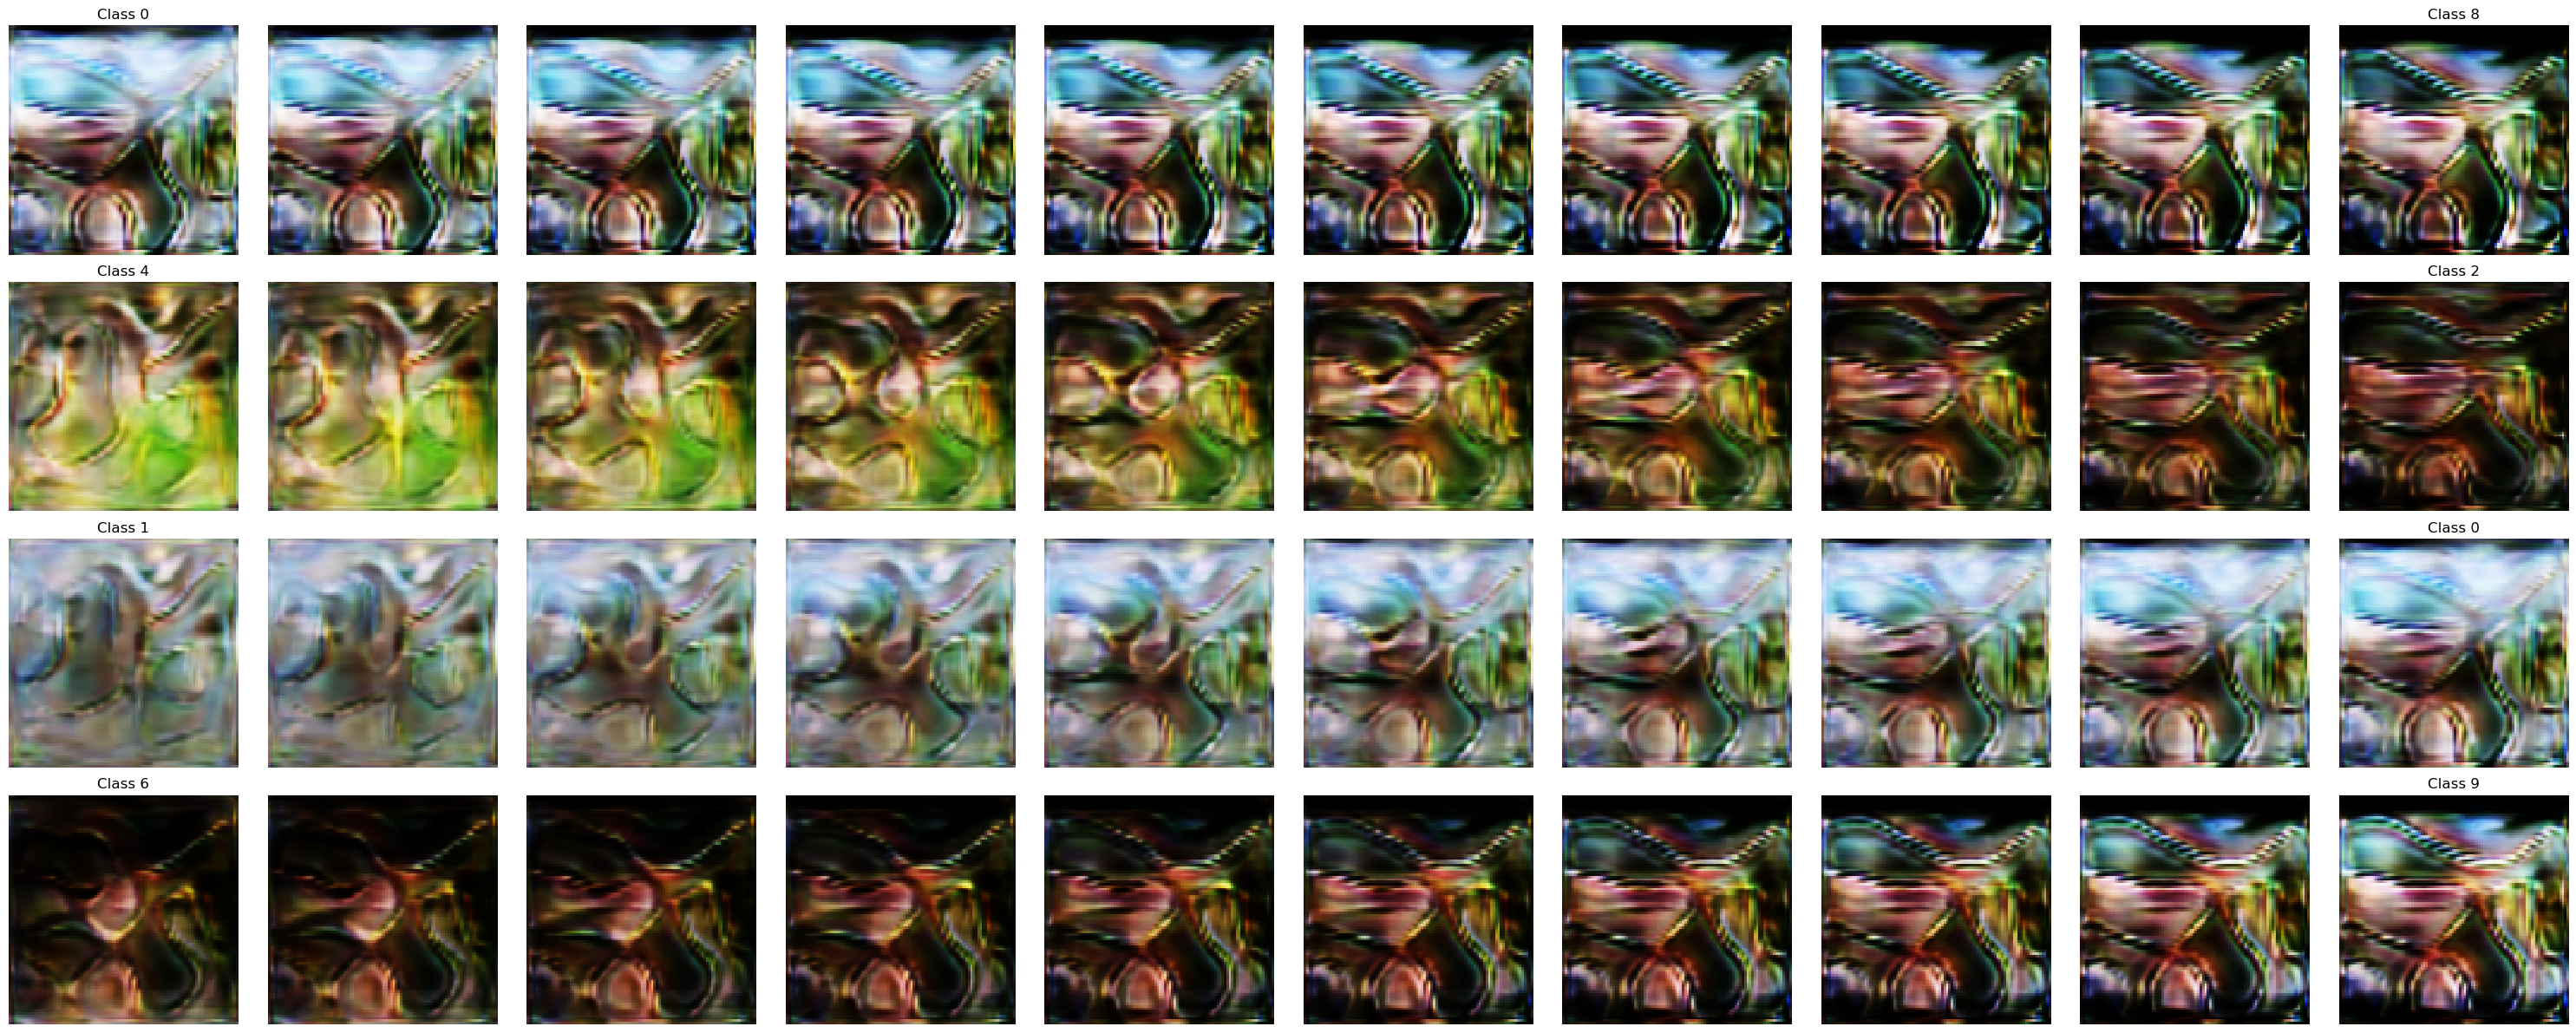

In [1]:
#!/usr/bin/env python3
"""
Complete runnable script: CLIP-conditioned GAN on STL-10 with SLERP blending, AMP, checkpointing.
Saves checkpoints and visualizations. Attempts to pip-install missing packages automatically.
Save as run_gan_clip.py and run: python run_gan_clip.py
"""

import os
import sys
import time
import math
import argparse
import subprocess
from pathlib import Path

# -------------------------
# Auto-install missing packages (best-effort)
# -------------------------
def _pip_install(pkg):
    print(f"[installer] pip installing {pkg} ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

try:
    import torch
    import torchvision
    import torchvision.transforms as T
    import torchvision.datasets as datasets
    import numpy as np
    import matplotlib.pyplot as plt
    import PIL
except Exception as e:
    print("Missing core packages; attempting to install torch, torchvision, pillow, matplotlib, numpy")
    _pip_install("torch")
    _pip_install("torchvision")
    _pip_install("pillow")
    _pip_install("matplotlib")
    _pip_install("numpy")
    import torch
    import torchvision
    import torchvision.transforms as T
    import torchvision.datasets as datasets
    import numpy as np
    import matplotlib.pyplot as plt
    import PIL

# open_clip may be missing
try:
    import open_clip
except Exception:
    try:
        _pip_install("open_clip_torch")
        import open_clip
    except Exception as e:
        print("Failed to install open_clip_torch automatically. Please install manually: pip install open_clip_torch")
        raise

# -------------------------
# CONFIG (edit these as needed)
# -------------------------
ROOT = Path.cwd() / "gan_clip_run"
ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = ROOT / "outputs"
CKPT_DIR = ROOT / "checkpoints"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "batch_size": 64,
    "lr_g": 2e-4,
    "lr_d": 1e-4,
    "epochs": 20,
    "img_size": 96,
    "embed_dim": 512,         # CLIP embedding dim (ViT-B-32 gives 512)
    "output_dir": str(OUTPUT_DIR),
    "checkpoint_dir": str(CKPT_DIR),
    "print_every": 50,
    "recon_weight": 100.0,    # tuneable
    "grad_clip": 1.0,
    "use_amp": True
}

print("Config:", CONFIG)
print("Device:", CONFIG["device"])

# -------------------------
# Dataset + DataLoader
# -------------------------
from torch.utils.data import DataLoader

def get_stl10_loader(batch_size, img_size, download_root):
    transform = T.Compose([
        T.Resize(img_size),
        T.CenterCrop(img_size),
        T.ToTensor(),
        T.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    ])
    ds = datasets.STL10(root=download_root, split='train', download=True, transform=transform)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=4, pin_memory=True)
    return loader, ds

# -------------------------
# Models: CLIP Encoder wrapper, Generator, Discriminator
# -------------------------
import torch.nn as nn
import torch.nn.functional as F

class CLIPEncoder(nn.Module):
    def __init__(self, model_name="ViT-B-32", pretrained="laion2b_s34b_b79k"):
        super().__init__()
        # create_model_and_transforms returns (model, _, preprocess) but we only use model
        model, _, _ = open_clip.create_model_and_transforms(model_name, pretrained=pretrained)
        model.eval()
        self.model = model.to(CONFIG["device"])
        # statistics for openclip pretrained models (ViT uses same)
        self.register_buffer("clip_mean", torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1,3,1,1))
        self.register_buffer("clip_std",  torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1,3,1,1))

    @torch.no_grad()
    def forward(self, images):
        # images expected in [-1,1]; convert to [0,1], resize to 224, normalize
        x = (images + 1.0) * 0.5
        x = F.interpolate(x, size=(224,224), mode='bilinear', align_corners=False)
        x = (x - self.clip_mean.to(x.device)) / self.clip_std.to(x.device)
        feats = self.model.encode_image(x)
        feats = feats.float()
        # normalize to unit norm across last dim for stability
        feats = feats / (feats.norm(dim=-1, keepdim=True) + 1e-6)
        return feats

# Generator: maps CLIP embedding (or batch of embeddings) to image
class Generator(nn.Module):
    def __init__(self, embed_dim=512, init_h=6, dim=256):
        super().__init__()
        self.init_h = init_h
        self.dim = dim
        self.fc = nn.Linear(embed_dim, dim * init_h * init_h)
        # Upsample blocks
        self.blocks = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(dim, dim//2, 3, 1, 1), nn.BatchNorm2d(dim//2), nn.LeakyReLU(0.2, True),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(dim//2, dim//4, 3, 1, 1), nn.BatchNorm2d(dim//4), nn.LeakyReLU(0.2, True),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(dim//4, dim//8, 3, 1, 1), nn.BatchNorm2d(dim//8), nn.LeakyReLU(0.2, True),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(dim//8, dim//16, 3, 1, 1), nn.BatchNorm2d(dim//16), nn.LeakyReLU(0.2, True),

            nn.Conv2d(dim//16, 3, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, x):
        # x: [B, embed_dim]
        x = self.fc(x)
        x = x.view(x.size(0), self.dim, self.init_h, self.init_h)
        return self.blocks(x)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self, img_size=96):
        super().__init__()
        def d_block(in_c, out_c, bn=True):
            layers = [nn.Conv2d(in_c, out_c, 4, 2, 1), nn.LeakyReLU(0.2, True)]
            if bn:
                layers.append(nn.BatchNorm2d(out_c))
            return layers
        # 96 -> 48 -> 24 -> 12 -> 6
        self.model = nn.Sequential(
            *d_block(3, 32, bn=False),  # 96->48
            *d_block(32, 64),           # 48->24
            *d_block(64, 128),          # 24->12
            *d_block(128, 256),         # 12->6
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 1)
        )

    def forward(self, x):
        return self.model(x)

# -------------------------
# Utilities: checkpoint, slerp, save image
# -------------------------
def slerp_batch(a, b, t: float):
    # a,b: [B, D]
    a_n = F.normalize(a, dim=-1)
    b_n = F.normalize(b, dim=-1)
    dot = (a_n * b_n).sum(dim=-1).clamp(-1+1e-6, 1-1e-6)
    omega = torch.acos(dot)
    so = torch.sin(omega)
    t = float(t)
    small = (so.abs() < 1e-6)
    coeff1 = torch.where(small, 1.0 - t, torch.sin((1.0 - t) * omega) / so)
    coeff2 = torch.where(small, t, torch.sin(t * omega) / so)
    coeff1 = coeff1.unsqueeze(1)
    coeff2 = coeff2.unsqueeze(1)
    return coeff1 * a + coeff2 * b

def save_checkpoint(generator, discriminator, opt_g, opt_d, epoch):
    pgen = Path(CONFIG["checkpoint_dir"]) / "generator.pt"
    pdis = Path(CONFIG["checkpoint_dir"]) / "discriminator.pt"
    torch.save({"epoch": epoch, "model": generator.state_dict(), "opt": opt_g.state_dict()}, str(pgen))
    torch.save({"epoch": epoch, "model": discriminator.state_dict(), "opt": opt_d.state_dict()}, str(pdis))
    print(f"[ckpt] saved epoch {epoch} -> {pgen}, {pdis}")

def load_checkpoint(generator, discriminator, opt_g=None, opt_d=None):
    pgen = Path(CONFIG["checkpoint_dir"]) / "generator.pt"
    pdis = Path(CONFIG["checkpoint_dir"]) / "discriminator.pt"
    start_epoch = 0
    if pgen.exists():
        ck = torch.load(str(pgen), map_location=CONFIG["device"])
        generator.load_state_dict(ck["model"])
        if opt_g is not None:
            opt_g.load_state_dict(ck["opt"])
        start_epoch = ck.get("epoch", 0) + 1
        print(f"[ckpt] loaded generator epoch {ck.get('epoch',0)}")
    if pdis.exists():
        ck = torch.load(str(pdis), map_location=CONFIG["device"])
        discriminator.load_state_dict(ck["model"])
        if opt_d is not None:
            opt_d.load_state_dict(ck["opt"])
        print(f"[ckpt] loaded discriminator epoch {ck.get('epoch',0)}")
    return start_epoch

def tensor_to_image(tensor):
    # tensor in [-1,1], shape [3,H,W]
    img = (tensor.clamp(-1,1) + 1.0) / 2.0
    np_img = (img.cpu().permute(1,2,0).numpy() * 255).astype('uint8')
    return np_img

# -------------------------
# Training loop
# -------------------------
def train_gan():
    # prepare dataloader
    loader, dataset = get_stl10_loader(CONFIG["batch_size"], CONFIG["img_size"], ROOT / "data")
    encoder = CLIPEncoder()
    generator = Generator(embed_dim=CONFIG["embed_dim"]).to(CONFIG["device"])
    discriminator = Discriminator(img_size=CONFIG["img_size"]).to(CONFIG["device"])

    opt_g = torch.optim.Adam(generator.parameters(), lr=CONFIG["lr_g"], betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=CONFIG["lr_d"], betas=(0.5, 0.999))

    adversarial_loss = nn.BCEWithLogitsLoss()
    recon_loss = nn.L1Loss()

    scaler = torch.cuda.amp.GradScaler(enabled=CONFIG["use_amp"])

    start_epoch = load_checkpoint(generator, discriminator, opt_g, opt_d)
    total_steps = 0

    for epoch in range(start_epoch, CONFIG["epochs"]):
        t0 = time.time()
        generator.train(); discriminator.train()
        for i, (real_imgs, _) in enumerate(loader):
            real_imgs = real_imgs.to(CONFIG["device"], non_blocking=True)
            bs = real_imgs.size(0)
            valid = torch.ones(bs, 1, device=CONFIG["device"])
            fake_labels = torch.zeros(bs, 1, device=CONFIG["device"])

            # 1) Train Discriminator
            opt_d.zero_grad()
            with torch.no_grad():
                embeddings = encoder(real_imgs)  # [B, D]

            with torch.cuda.amp.autocast(enabled=CONFIG["use_amp"]):
                fake_imgs = generator(embeddings)
                pred_real = discriminator(real_imgs)
                pred_fake = discriminator(fake_imgs.detach())
                d_real_loss = adversarial_loss(pred_real, valid)
                d_fake_loss = adversarial_loss(pred_fake, fake_labels)
                d_loss = 0.5 * (d_real_loss + d_fake_loss)

            scaler.scale(d_loss).backward()
            if CONFIG["grad_clip"] is not None:
                scaler.unscale_(opt_d)
                torch.nn.utils.clip_grad_norm_(discriminator.parameters(), CONFIG["grad_clip"])
            scaler.step(opt_d)
            scaler.update()

            # 2) Train Generator
            opt_g.zero_grad()
            with torch.cuda.amp.autocast(enabled=CONFIG["use_amp"]):
                fake_imgs = generator(embeddings)
                pred = discriminator(fake_imgs)
                g_adv = adversarial_loss(pred, valid)
                g_rec = recon_loss(fake_imgs, real_imgs)
                g_loss = g_adv + CONFIG["recon_weight"] * g_rec

            scaler.scale(g_loss).backward()
            if CONFIG["grad_clip"] is not None:
                scaler.unscale_(opt_g)
                torch.nn.utils.clip_grad_norm_(generator.parameters(), CONFIG["grad_clip"])
            scaler.step(opt_g)
            scaler.update()

            if (i % CONFIG["print_every"]) == 0:
                print(f"[Epoch {epoch+1}/{CONFIG['epochs']}] Batch {i}/{len(loader)} "
                      f"D_loss={d_loss.item():.4f} G_adv={g_adv.item():.4f} G_rec={g_rec.item():.4f}")

            total_steps += 1

        # epoch end
        save_checkpoint(generator, discriminator, opt_g, opt_d, epoch)
        print(f"Epoch {epoch+1} finished in {time.time()-t0:.1f}s")

    return encoder, generator, dataset

# -------------------------
# Visualization & blending demo
# -------------------------
def visualize_blends(encoder, generator, dataset, pairs=[(0,8),(4,2),(1,0),(6,9)], steps=10):
    # build example images per class label
    examples = {}
    for idx in range(len(dataset)):
        img, lbl = dataset[idx]
        if lbl not in examples:
            examples[lbl] = img
        if len(examples) >= max(max(a,b) for a,b in pairs)+1:
            break

    generator.eval()
    with torch.no_grad():
        fig, axes = plt.subplots(len(pairs), steps, figsize=(3*steps, 3*len(pairs)))
        for r,(c1,c2) in enumerate(pairs):
            img1 = examples[c1].unsqueeze(0).to(CONFIG["device"])
            img2 = examples[c2].unsqueeze(0).to(CONFIG["device"])
            emb1 = encoder(img1)  # [1, D]
            emb2 = encoder(img2)
            for col, alpha in enumerate(np.linspace(0,1,steps)):
                mixed = slerp_batch(emb1, emb2, float(alpha))
                out = generator(mixed)
                np_img = tensor_to_image(out[0])
                ax = axes[r, col] if len(pairs) > 1 else axes[col]
                ax.imshow(np_img)
                ax.axis("off")
                if col == 0: ax.set_title(f"Class {c1}")
                if col == steps-1: ax.set_title(f"Class {c2}")
        plt.tight_layout()
        p = Path(CONFIG["output_dir"]) / "blends.png"
        plt.savefig(p, bbox_inches='tight')
        print(f"Saved blend visualization to {p}")

# -------------------------
# Main
# -------------------------
if __name__ == "__main__":
    print("Starting training run...")
    enc, gen, ds = train_gan()
    print("Training finished. Running visualize_blends...")
    visualize_blends(enc, gen, ds)
    print("Done. Outputs in:", CONFIG["output_dir"], "Checkpoints in:", CONFIG["checkpoint_dir"])


In [2]:
# Cell 1: install required packages (run in notebook cell)
import sys, subprocess
pkgs = ["torch", "torchvision", "tqdm", "Pillow", "open_clip_torch", "matplotlib"]
for p in pkgs:
    try:
        __import__(p.split()[0])
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", p])
print("Packages ready")


Packages ready


In [11]:
# Cell 2: imports & config
import os, json, random, time, math, urllib.request, zipfile, shutil
from pathlib import Path
from tqdm import tqdm
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
import open_clip

ROOT = Path.cwd() / "morph_project"
DATA_ROOT = ROOT / "data"
COCO_DIR = DATA_ROOT / "coco"
CHECKPOINTS = ROOT / "checkpoints"
LATENT_DIR = ROOT / "latents"
OUT = ROOT / "outputs"
for p in (DATA_ROOT, COCO_DIR, CHECKPOINTS, LATENT_DIR, OUT):
    p.mkdir(parents=True, exist_ok=True)

CFG = {
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "img_size": 128,
    "compressor_bs": 32,
    "compressor_epochs": 8,     # increase for real training
    "compressor_lr": 2e-4,
    "vq_codes": 1024,
    "vq_dim": 256,
    "ldm_bs": 64,
    "ldm_epochs": 40,           # increase for final runs
    "ldm_lr": 1e-4,
    "ldm_timesteps": 1000,
    "latent_downsample": 8,     # img_size / (latent H) = 8 -> H = 32
    "clip_model": "ViT-B-32",
    "clip_pretrained": "laion2b_s34b_b79k",
    "seed": 42
}
torch.manual_seed(CFG["seed"]); random.seed(CFG["seed"])
device = torch.device(CFG["device"])
print("Device:", device)


Device: cuda


In [4]:
# Cell 3: download COCO val2017 and annotations if needed, then filter animal captions
COCO_VAL_URL = "http://images.cocodataset.org/zips/val2017.zip"
COCO_ANN_URL = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
zip_images = COCO_DIR / "val2017.zip"
zip_ann = COCO_DIR / "annotations_trainval2017.zip"
images_folder = COCO_DIR / "val2017"
ann_folder = COCO_DIR / "annotations"
meta_file = COCO_DIR / "animal_meta.json"

def download_if_missing(url, dest):
    if dest.exists(): return
    print("Downloading", url)
    tmp = str(dest) + ".tmp"
    urllib.request.urlretrieve(url, tmp)
    shutil.move(tmp, dest)
    print("Saved", dest)

# try download (may take time)
if not images_folder.exists() or not ann_folder.exists():
    try:
        download_if_missing(COCO_VAL_URL, zip_images)
        download_if_missing(COCO_ANN_URL, zip_ann)
        print("Extracting (this will take a while)...")
        with zipfile.ZipFile(zip_images, 'r') as z: z.extractall(COCO_DIR)
        with zipfile.ZipFile(zip_ann, 'r') as z: z.extractall(COCO_DIR)
    except Exception as e:
        print("Automatic download/extract failed:", e)
        print("If download fails, place val2017 and annotations folder under:", COCO_DIR)
        raise

# build animal metadata from captions (coarse keyword filter)
if not meta_file.exists():
    captions_path = ann_folder / "captions_val2017.json"
    with open(captions_path, 'r') as f:
        caps = json.load(f)
    id2fname = {img['id']: img['file_name'] for img in caps['images']}
    animal_kws = {"dog","cat","horse","sheep","cow","elephant","bear","zebra","giraffe","bird","fish","seal","alligator","crocodile","lion","tiger","otter","whale"}
    meta=[]
    used=set()
    for ann in caps['annotations']:
        txt = ann.get("caption","").lower()
        if any(k in txt for k in animal_kws):
            imgid = ann['image_id']
            if imgid in used: continue
            used.add(imgid)
            meta.append((id2fname[imgid], ann.get("caption","")))
            if len(meta) >= 20000: break
    with open(meta_file, 'w') as f: json.dump(meta, f)
    print("Saved metadata with", len(meta))
else:
    print("Metadata exists:", meta_file)


Saved /home/gedo/Documents/cv_project/morph_project/data/coco/val2017.zip
Saved /home/gedo/Documents/cv_project/morph_project/data/coco/annotations_trainval2017.zip
Extracting (this will take a while)...
Saved metadata with 1248


In [9]:
import os
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as T

class AnimalDataset(Dataset):
    def __init__(self, meta, root, img_size=256):
        self.meta = meta            # list of dicts: {"path": "...", "label": "..."}
        self.root = Path(root)

        # IMPORTANT: do NOT overwrite variable name "transforms"
        self.tf = T.Compose([
            T.Resize(img_size),
            T.CenterCrop(img_size),
            T.ToTensor(),
            T.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        item = self.meta[idx]
        
        # Case A: dict
        if isinstance(item, dict):
            img_path = self.root / item["path"]
            label = item.get("label", -1)
        
        # Case B: tuple or list: (path, label)
        elif isinstance(item, (tuple, list)):
            img_path = self.root / item[0]
            label = item[1] if len(item) > 1 else -1
            
        else:
            raise TypeError(f"Unsupported meta format: {type(item)}")
        
        img = Image.open(img_path).convert("RGB")
        img = self.tf(img)
        return img, label



# split
random.shuffle(META)
val_split = int(0.05 * len(META))
train_meta = META[:-val_split]
val_meta = META[-val_split:]
train_ds = AnimalDataset(train_meta, IMG_ROOT)
val_ds = AnimalDataset(val_meta, IMG_ROOT)
train_loader = DataLoader(train_ds, batch_size=CFG["compressor_bs"], shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=CFG["compressor_bs"], shuffle=False, num_workers=4, pin_memory=True)
print("Train len:", len(train_ds), "Val len:", len(val_ds))


Train len: 1186 Val len: 62


In [7]:
# Cell 5: compressor model code
class Encoder(nn.Module):
    def __init__(self, in_ch=3, base=CFG["compressor_channels"] if "compressor_channels" in CFG else 128, zdim=CFG["vq_dim"]):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, base, 4,2,1), nn.ReLU(),
            nn.Conv2d(base, base*2, 4,2,1), nn.ReLU(),
            nn.Conv2d(base*2, base*4, 4,2,1), nn.ReLU(),
            nn.Conv2d(base*4, zdim, 1)
        )
    def forward(self,x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self, out_ch=3, base=CFG.get("compressor_channels",128), zdim=CFG["vq_dim"]):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(zdim, base*4, 3,1,1), nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(base*4, base*2, 3,1,1), nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(base*2, base, 3,1,1), nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(base, out_ch, 3,1,1),
            nn.Tanh()
        )
    def forward(self,z): return self.net(z)

class VectorQuantizer(nn.Module):
    def __init__(self, num_codes=CFG["vq_codes"], code_dim=CFG["vq_dim"], beta=0.25):
        super().__init__()
        self.embedding = nn.Embedding(num_codes, code_dim)
        nn.init.uniform_(self.embedding.weight, -1.0/num_codes, 1.0/num_codes)
        self.beta = beta
    def forward(self, z):
        # z: [B,C,H,W]
        B,C,H,W = z.shape
        flat = z.permute(0,2,3,1).contiguous().view(-1, C)  # [B*H*W, C]
        # distances
        emb = self.embedding.weight  # [K, C]
        d = (flat.pow(2).sum(1, keepdim=True) - 2*flat @ emb.t() + emb.pow(2).sum(1).unsqueeze(0))
        idx = d.argmin(1)
        quant = emb[idx].view(B,H,W,C).permute(0,3,1,2).contiguous()
        # losses
        q_loss = F.mse_loss(quant, z.detach())
        e_loss = F.mse_loss(quant.detach(), z)
        loss = q_loss + self.beta * e_loss
        quant = z + (quant - z).detach()
        idx = idx.view(B,H,W)
        return quant, loss, idx

print("Models defined")


Models defined


In [15]:
# Cell 6: train compressor
enc = Encoder().to(device)
vq = VectorQuantizer().to(device)
dec = Decoder().to(device)
opt = torch.optim.Adam(list(enc.parameters())+list(vq.parameters())+list(dec.parameters()), lr=CFG["compressor_lr"])
recon_crit = nn.L1Loss()
CKPT_COMP = CHECKPOINTS / "compressor.pt"

start_epoch = 0
if CKPT_COMP.exists():
    ck = torch.load(CKPT_COMP, map_location=device)
    enc.load_state_dict(ck["enc"]); vq.embedding.load_state_dict(ck["vq"]); dec.load_state_dict(ck["dec"]); opt.load_state_dict(ck["opt"])
    start_epoch = ck.get("epoch",0) + 1
    print("Resumed compressor from epoch", start_epoch)

for ep in range(start_epoch, CFG["compressor_epochs"]):
    enc.train(); vq.train(); dec.train()
    tot = 0.0
    for imgs, _ in tqdm(train_loader, desc=f"Comp ep{ep}"):
        imgs = imgs.to(device)
        z = enc(imgs)
        quant, vq_loss, _ = vq(z)
        recon = dec(quant)
        rec_l = recon_crit(recon, imgs)
        loss = rec_l + vq_loss
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item()
    avg = tot / len(train_loader)
    torch.save({"enc":enc.state_dict(),"vq":vq.embedding.state_dict(),"dec":dec.state_dict(),"opt":opt.state_dict(),"epoch":ep}, CKPT_COMP)
    print(f"[Compressor] epoch {ep} avg_loss {avg:.4f}")
print("Compressor training done")


Comp ep0:   0%|          | 0/38 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 256.00 MiB. GPU 0 has a total capacity of 3.81 GiB of which 15.50 MiB is free. Including non-PyTorch memory, this process has 3.06 GiB memory in use. Process 705805 has 740.00 MiB memory in use. Of the allocated memory 2.43 GiB is allocated by PyTorch, and 541.71 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# Cell 7: encode all images to quantized continuous latents (save one .pt per sample)
enc.eval(); vq.eval(); dec.eval()
LAT_DIR = LATENT_DIR / "quant"
LAT_DIR.mkdir(parents=True, exist_ok=True)
index_list = []
cnt = 0
with torch.no_grad():
    for imgs, caps in tqdm(train_loader, desc="Encoding train latents"):
        imgs = imgs.to(device)
        z = enc(imgs)
        quant, _, idx = vq(z)
        for b in range(quant.size(0)):
            fname = LAT_DIR / f"latent_{cnt:07d}.pt"
            torch.save({"quant": quant[b].cpu(), "idx": idx[b].cpu(), "caption": caps[b]}, fname)
            index_list.append(str(fname))
            cnt += 1
with open(LATENT_DIR / "index.txt", "w") as f:
    f.write("\n".join(index_list))
print("Saved", cnt, "latents")


In [ ]:
# Cell 8: Latent UNet + LDM training. Conditioning: CLIP image embedding fed via linear->FiLM add.
class SmallResBlock(nn.Module):
    def __init__(self,ch): super().__init__(); self.conv = nn.Sequential(nn.Conv2d(ch,ch,3,1,1), nn.GroupNorm(8,ch), nn.SiLU())
    def forward(self,x): return x + self.conv(x)

class LatentUNetCond(nn.Module):
    def __init__(self, in_ch=CFG["vq_dim"], base=128, cond_dim=512):
        super().__init__()
        self.inc = nn.Conv2d(in_ch, base, 3,1,1)
        self.down1 = nn.Conv2d(base, base*2, 4,2,1)
        self.down2 = nn.Conv2d(base*2, base*4, 4,2,1)
        self.mid = nn.Sequential(SmallResBlock(base*4), SmallResBlock(base*4))
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 4,2,1)
        self.up1 = nn.ConvTranspose2d(base*2, base, 4,2,1)
        self.out = nn.Conv2d(base, in_ch, 3,1,1)
        # conditioning: map cond vector -> channel-wise scale & shift for FiLM at mid
        self.cond_proj = nn.Sequential(nn.Linear(cond_dim, base*4*2), nn.SiLU())
    def forward(self, x, cond):  # x: [B,C,H,W], cond: [B,cond_dim]
        x1 = F.silu(self.inc(x))
        x2 = F.silu(self.down1(x1))
        x3 = F.silu(self.down2(x2))
        # FiLM on mid
        gamma_beta = self.cond_proj(cond)  # [B, base*4*2]
        gamma, beta = gamma_beta.chunk(2, dim=-1)
        gamma = gamma.view(-1, x3.size(1),1,1); beta = beta.view(-1, x3.size(1),1,1)
        m = self.mid(x3)
        m = m * (1 + gamma) + beta
        u2 = F.silu(self.up2(m) + x2)
        u1 = F.silu(self.up1(u2) + x1)
        return self.out(u1)

# dataset for latents
class LatentFiles(Dataset):
    def __init__(self, index_file):
        with open(index_file,'r') as f: self.files = [l.strip() for l in f if l.strip()]
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        d = torch.load(self.files[i])
        # quant tensor is [C,H,W], convert to float32
        q = d["quant"].float()
        # caption available if needed: d["caption"]
        return q, self.files[i]

# CLIP model for image embeddings (frozen)
clip_model, clip_preproc, _ = open_clip.create_model_and_transforms(CFG["clip_model"], pretrained=CFG["clip_pretrained"])
clip_model.to(device).eval()
def clip_image_embed(img_tensor):  # img_tensor in [-1,1], Bx3xHxW
    x = (img_tensor + 1) * 0.5
    x = F.interpolate(x, size=(224,224), mode='bilinear', align_corners=False)
    # normalize for CLIP (open_clip transform uses same mean/std)
    # open_clip preprocess would do similar; use model.encode_image directly
    with torch.no_grad():
        feat = clip_model.encode_image(x.to(device))
        feat = feat / (feat.norm(dim=-1, keepdim=True) + 1e-9)
    return feat

# training loop
latent_index = LATENT_DIR / "index.txt"
ld_dataset = LatentFiles(str(latent_index))
ld_loader = DataLoader(ld_dataset, batch_size=min(CFG["ldm_bs"], len(ld_dataset)), shuffle=True, num_workers=4)
ldm = LatentUNetCond().to(device)
opt_ldm = torch.optim.Adam(ldm.parameters(), lr=CFG["ldm_lr"])
timesteps = CFG["ldm_timesteps"]
betas = torch.linspace(1e-4, 0.02, timesteps).to(device)
alphas = 1 - betas; alpha_cum = torch.cumprod(alphas, dim=0)

CKPT_LDM = CHECKPOINTS / "ldm.pt"
start = 0
if CKPT_LDM.exists():
    ck = torch.load(CKPT_LDM, map_location=device); ldm.load_state_dict(ck["model"]); opt_ldm.load_state_dict(ck["opt"]); start = ck.get("epoch",0)+1
for ep in range(start, CFG["ldm_epochs"]):
    ldm.train()
    running=0.0
    for q_batch, fpath in tqdm(ld_loader, desc=f"LDM ep{ep}"):
        # q_batch shape [B,C,H,W] stored on CPU, move to device
        q_batch = q_batch.to(device)
        B = q_batch.size(0)
        # obtain CLIP image conditioning by decoding quant -> image via decoder, then embed
        # We'll load decoder from compressor checkpoint to decode; if not available, skip conditioning.
        # Try to load decoder weights
        try:
            CKPT_COMP = CHECKPOINTS / "compressor.pt"
            ck = torch.load(CKPT_COMP, map_location=device)
            dec = Decoder().to(device); dec.load_state_dict(ck["dec"])
            dec.eval()
            with torch.no_grad():
                recon_img = dec(q_batch)  # [-1,1]
                cond = clip_image_embed(recon_img)  # [B,512]
        except Exception:
            # fallback: zero condition
            cond = torch.zeros(B,512, device=device)
        # sample t and noise
        t = torch.randint(0, timesteps, (B,), device=device)
        a = alpha_cum[t].view(B,1,1,1)
        noise = torch.randn_like(q_batch)
        noisy = torch.sqrt(a) * q_batch + torch.sqrt(1-a) * noise
        pred = ldm(noisy, cond)
        loss = F.mse_loss(pred, noise)
        opt_ldm.zero_grad(); loss.backward(); opt_ldm.step()
        running += loss.item()
    avg = running / len(ld_loader)
    torch.save({"model":ldm.state_dict(),"opt":opt_ldm.state_dict(),"epoch":ep}, CKPT_LDM)
    print(f"[LDM] ep{ep} loss {avg:.4f}")
print("LDM training done")


In [ ]:
# Cell 9: sampling from LDM (few steps) and decode with decoder; blend two images via slerp of quant latents
@torch.no_grad()
def sample_ldm(ldm_ckpt, dec_ckpt, n=4, steps=50):
    ck = torch.load(ldm_ckpt, map_location=device)
    ldm = LatentUNetCond().to(device); ldm.load_state_dict(ck["model"]); ldm.eval()
    ck2 = torch.load(dec_ckpt, map_location=device)
    dec = Decoder().to(device); dec.load_state_dict(ck2["dec"]); dec.eval()
    C = CFG["vq_dim"]; H = CFG["img_size"]//CFG["latent_downsample"]; W=H
    x = torch.randn(n, C, H, W, device=device)
    timesteps = CFG["ldm_timesteps"]
    skip = max(1, timesteps // steps)
    for t in reversed(range(0, timesteps, skip)):
        # predict noise (no conditioning in sampling for simplicity)
        pred = ldm(x, torch.zeros(n,512,device=device))
        # simple Euler-like step
        x = x - pred * 0.1
    recons = dec(x)
    imgs=[]
    for i in range(recons.size(0)):
        im = (recons[i].cpu().permute(1,2,0).numpy() + 1)/2.0
        imgs.append((im*255).astype('uint8'))
    return imgs

# decode single latent file and return image (for blend)
def decode_latent_file(fp):
    d = torch.load(fp)
    q = d["quant"].unsqueeze(0).to(device)
    # decode with compressor dec
    ck = torch.load(CHECKPOINTS / "compressor.pt", map_location=device)
    dec = Decoder().to(device); dec.load_state_dict(ck["dec"]); dec.eval()
    with torch.no_grad():
        out = dec(q)[0].cpu().permute(1,2,0).numpy()
    return ((out+1)/2.0*255).astype('uint8')

# blend two samples by loading their quant tensors, flatten, slerp, decode
def blend_latent_files(fpA, fpB, alpha=0.5):
    a = torch.load(fpA)["quant"].float().to(device)
    b = torch.load(fpB)["quant"].float().to(device)
    zA = a.view(1,-1); zB = b.view(1,-1)
    mixed = slerp_batch(zA, zB, float(alpha)).view_as(a)
    ck = torch.load(CHECKPOINTS / "compressor.pt", map_location=device)
    dec = Decoder().to(device); dec.load_state_dict(ck["dec"]); dec.eval()
    with torch.no_grad():
        out = dec(mixed.unsqueeze(0))[0].cpu().permute(1,2,0).numpy()
    return ((out+1)/2.0*255).astype('uint8')

# quick display helper
def show_grid(images, rows=1):
    import matplotlib.pyplot as plt
    fig, axs = plt.subplots(rows, math.ceil(len(images)/rows), figsize=(4*math.ceil(len(images)/rows),4*rows))
    axs = axs.flatten() if hasattr(axs,'flatten') else [axs]
    for ax,img in zip(axs, images):
        ax.imshow(img); ax.axis('off')
    plt.show()

# sample demo
# sample images if ldm trained
ldm_ckpt = CHECKPOINTS / "ldm.pt"
comp_ckpt = CHECKPOINTS / "compressor.pt"
if ldm_ckpt.exists() and comp_ckpt.exists():
    samples = sample_ldm(ldm_ckpt, comp_ckpt, n=4, steps=40)
    show_grid(samples, rows=1)
# blend two saved latents if available
idx_file = LATENT_DIR / "index.txt"
if idx_file.exists():
    files = open(idx_file).read().splitlines()
    if len(files) >= 2:
        blend_img = blend_latent_files(files[0], files[1], alpha=0.5)
        show_grid([blend_img], rows=1)
